# Projet 1 — Prédiction du succès d'une campagne marketing bancaire

**Membres du groupe :**
- ABEGUEDIE Rosane Yvanne Boyama  
- BARRY Mamoudou  
- DAMIENS Elodie  
- GUILLEMINOT Paul  
- TOUAMI Zakaria

**Groupe :** D  
**Jeu de données :** `bank-full.csv`  
**Objectif :** comprendre les facteurs associés à la souscription d'un produit d'épargne et construire un modèle capable d'aider la banque à mieux cibler ses appels.

## 1. Problématique et logique d'analyse

La banque mène des campagnes téléphoniques pour proposer un dépôt à terme à ses clients.  
La variable cible `y` indique si le client a finalement **souscrit (`yes`) ou non (`no`)**.

Dans ce notebook, on suit une démarche complète :

1. **Comprendre le dataset** et vérifier sa qualité.
2. **Explorer les données** pour identifier les profils les plus réceptifs.
3. **Tester statistiquement** certaines relations observées.
4. **Construire plusieurs modèles** de classification.
5. **Comparer les performances** et discuter les limites.
6. **Ajuster le seuil de décision** selon un objectif métier.

L'idée n'est pas seulement d'obtenir un bon score, mais de produire une analyse **claire, justifiée et interprétable**.

In [62]:

'''import warnings
warnings.filterwarnings("ignore")
Utile ??'''

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from scipy.stats import chi2_contingency, mannwhitneyu

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay,
    precision_recall_curve
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, VotingClassifier

# XGBoost est utilisé seulement s'il est disponible
try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
except Exception:
    HAS_XGBOOST = False

# Style graphique
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

## 2. Chargement des données

On commence par charger le fichier CSV puis par vérifier sa structure générale.  
Cette étape est indispensable car elle permet de répondre aux premières questions :

- combien y a-t-il d'observations ?
- combien y a-t-il de variables ?
- quels sont les types de colonnes ?
- la cible est-elle équilibrée ou non ?

### But et utilité de l'étape

**But :** charger les données dans un format exploitable et vérifier rapidement leur structure (taille, types, valeurs manquantes).

**Utilité :** valider qu'on travaille sur le bon périmètre avant toute interprétation ou modélisation.


In [64]:
data = pd.read_csv("bank-full.csv", sep=";")
display(data.head())

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [65]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


### Lecture initiale

Le dataset contient des variables :

- **sociodémographiques** : `age`, `job`, `marital`, `education`
- **financières** : `balance`, `default`, `housing`, `loan`
- **liées à la campagne** : `contact`, `day`, `month`, `duration`, `campaign`
- **liées à l'historique marketing** : `pdays`, `previous`, `poutcome`
- **cible** : `y`

On est donc bien dans un problème de **classification binaire**.

## 3. Data canvas — compréhension des variables

Avant de modéliser, il faut expliciter le rôle des variables.  
Cette étape aide à distinguer :

- les variables probablement **prédictives** ;
- les variables possiblement **redondantes** ;
- les variables qui peuvent créer un **biais de fuite d'information**.

### But et utilité de l'étape

**But :** décrire les variables métier et leur rôle potentiel dans la prédiction.

**Utilité :** éviter les erreurs de lecture (variables redondantes, ambiguïté métier, risque de fuite d'information).


In [66]:
description = pd.DataFrame({
    "variable": data.columns,
    "type": data.dtypes.astype(str).values,
    "nb_modalites_ou_infos": [data[col].nunique() for col in data.columns],
    "exemple": [data[col].dropna().iloc[0] if data[col].notna().any() else np.nan for col in data.columns]
})

display(description)

,variable,type,nb_modalites_ou_infos,exemple
0,age,int64,77,58
1,job,object,12,management
2,marital,object,3,married
3,education,object,4,tertiary
4,default,object,2,no
5,balance,int64,7168,2143
6,housing,object,2,yes
7,loan,object,2,no
8,contact,object,3,unknown
9,day,int64,31,5


### Hypothèses métier formulées avant l'EDA

Avant même les graphiques, on peut déjà poser quelques hypothèses raisonnables :

- un client déjà réceptif par le passé (`poutcome = success`) devrait avoir une probabilité de souscription plus élevée (cf partie 15);
- un grand nombre de relances (`campaign`) peut traduire une difficulté à convaincre (cf partie 15);
- certaines professions ou niveaux d'études peuvent être associés à une meilleure réceptivité (cf partie 15);
- `duration` risque d'être **très prédictive**, mais cette variable est problématique d'un point de vue métier, car la durée n'est connue **qu'après l'appel** (cf partie 11)

## 4. Analyse de la cible

Il faut toujours commencer par regarder la variable cible.  
Pourquoi ? Parce qu'un déséquilibre entre classes influence :

- le choix des métriques ;
- le choix éventuel de `class_weight`;
- l'interprétation des scores.

### But et utilité de l'étape

**But :** mesurer la répartition de `y` et poser les hypothèses initiales sur les facteurs explicatifs.

**Utilité :** orienter les choix de métriques, de validation et de traitement d'un éventuel déséquilibre de classes.


,y,effectif,proportion
0,no,39922,0.883
1,yes,5289,0.117


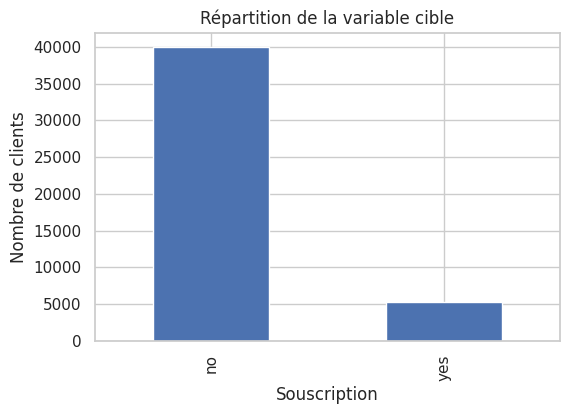

In [67]:
target_dist = (
    data["y"]
    .value_counts()
    .rename_axis("y")
    .reset_index(name="effectif")
)
target_dist["proportion"] = target_dist["effectif"] / len(data)

display(target_dist)

plt.figure(figsize=(6, 4))
data["y"].value_counts().sort_index().plot(kind="bar")
plt.title("Répartition de la variable cible")
plt.xlabel("Souscription")
plt.ylabel("Nombre de clients")
plt.show()

### Interprétation

La classe positive (`yes`) est nettement minoritaire.  
Cela signifie qu'un modèle qui prédirait presque toujours `no` pourrait afficher une accuracy correcte tout en étant peu utile en pratique.

**Conséquence méthodologique :** on ne se limitera pas à l'accuracy.  
On regardera aussi :

- la **précision** ;
- le **rappel** ;
- le **F1-score** ;
- la **ROC-AUC**.

## 5. Diagnostic de qualité des données

Avant l'EDA, on vérifie les problèmes les plus fréquents :

- valeurs manquantes ;
- doublons ;
- modalités ambiguës comme `unknown` ;
- valeurs atypiques ou extrêmes.

### But et utilité de l'étape

**But :** controler les anomalies de qualite (doublons, incoherences, modalites suspectes).

**Utilite :** fiabiliser l'analyse statistique et limiter les biais en aval.


In [68]:
quality = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "missing_values": data.isna().sum(),
    "missing_rate_%": (data.isna().mean() * 100).round(2),
    "n_unique": data.nunique()
})
display(quality)
print(f"Doublons exacts : {data.duplicated().sum():,}")

,dtype,missing_values,missing_rate_%,n_unique
age,int64,0,0.000,77
job,object,0,0.000,12
marital,object,0,0.000,3
education,object,0,0.000,4
default,object,0,0.000,2
balance,int64,0,0.000,7168
housing,object,0,0.000,2
loan,object,0,0.000,2
contact,object,0,0.000,3
day,int64,0,0.000,31


Doublons exacts : 0


### Premier constat

Il n'y a pas de valeurs manquantes explicites au sens Pandas, mais cela ne veut pas dire qu'il n'y a **aucune information absente**.

Dans ce dataset, certaines colonnes catégorielles utilisent la modalité **`unknown`** pour coder une information inconnue.  
Il faut donc la traiter comme une **pseudo-valeur manquante**.

## 6. Étude des modalités `unknown`

Cette étape est importante pour deux raisons :

1. sur le plan analytique, une forte présence de `unknown` peut réduire l'interprétabilité ;
2. sur le plan du machine learning, on doit décider si cette modalité est conservée telle quelle ou transformée en valeur manquante imputée.

In [69]:
object_cols = data.select_dtypes(include="object").columns.tolist()

unknown_rows = []
for col in object_cols:
    unknown_count = (data[col] == "unknown").sum()
    unknown_rows.append({
        "variable": col,
        "unknown_count": int(unknown_count),
        "unknown_rate_%": round(100 * unknown_count / len(data), 2)
    })

unknown_df = pd.DataFrame(unknown_rows).sort_values("unknown_rate_%", ascending=False)
display(unknown_df)

,variable,unknown_count,unknown_rate_%
8,poutcome,36959,81.750
6,contact,13020,28.800
2,education,1857,4.110
0,job,288,0.640
1,marital,0,0.000
3,default,0,0.000
5,loan,0,0.000
4,housing,0,0.000
7,month,0,0.000
9,y,0,0.000


In [70]:
unknown_effect_rows = []

for col in object_cols:
    if (data[col] == "unknown").sum() > 0:
        tmp = (
            data.assign(target_num=(data["y"] == "yes").astype(int))
            .groupby(col)["target_num"]
            .mean()
            .reset_index()
            .rename(columns={"target_num": "subscription_rate"})
        )
        tmp["variable"] = col
        unknown_effect_rows.append(tmp)

unknown_effect = pd.concat(unknown_effect_rows, ignore_index=True)
display(unknown_effect[unknown_effect.iloc[:, 0] == "unknown"].sort_values("subscription_rate"))

,job,subscription_rate,variable,education,contact,poutcome
11,unknown,0.118,job,NaN,NaN,NaN


### Interprétation

Les modalités `unknown` ne sont pas neutres : elles peuvent être associées à un comportement de souscription particulier.  
On ne doit donc pas les supprimer brutalement sans réflexion.

Dans la partie modélisation, on fera un choix intermédiaire :

- remplacer `unknown` par une valeur manquante ;
- imputer ensuite automatiquement via le pipeline.

Cela permet d'avoir une logique de traitement homogène.

## 7. Analyse des variables numériques et des valeurs extrêmes

Les valeurs extrêmes peuvent fausser :

- la lecture des distributions ;
- les moyennes ;
- certains modèles, en particulier la régression logistique.

On les observe donc avant de décider d'un traitement.

### But et utilité de l'étape

**But :** détecter les distributions asymétriques et les outliers sur les variables quantitatives.

**Utilite :** choisir un traitement robuste des extremes (ex. clipping IQR) sans perdre inutilement des observations.


In [71]:
numeric_cols = data.select_dtypes(include=np.number).columns.tolist()
display(data[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
age,"45,211.000",40.936,10.619,18.000,33.000,39.000,48.000,95.000
balance,"45,211.000","1,362.272","3,044.766","-8,019.000",72.000,448.000,"1,428.000","102,127.000"
day,"45,211.000",15.806,8.322,1.000,8.000,16.000,21.000,31.000
duration,"45,211.000",258.163,257.528,0.000,103.000,180.000,319.000,"4,918.000"
campaign,"45,211.000",2.764,3.098,1.000,1.000,2.000,3.000,63.000
pdays,"45,211.000",40.198,100.129,-1.000,-1.000,-1.000,-1.000,871.000
previous,"45,211.000",0.580,2.303,0.000,0.000,0.000,0.000,275.000


Les statistiques descriptives montrent une forte dispersion pour certaines variables comme balance, duration et pdays. Les valeurs maximales sont particulièrement élevées par rapport aux quartiles, ce qui suggère la présence de distributions asymétriques et de valeurs extrêmes.

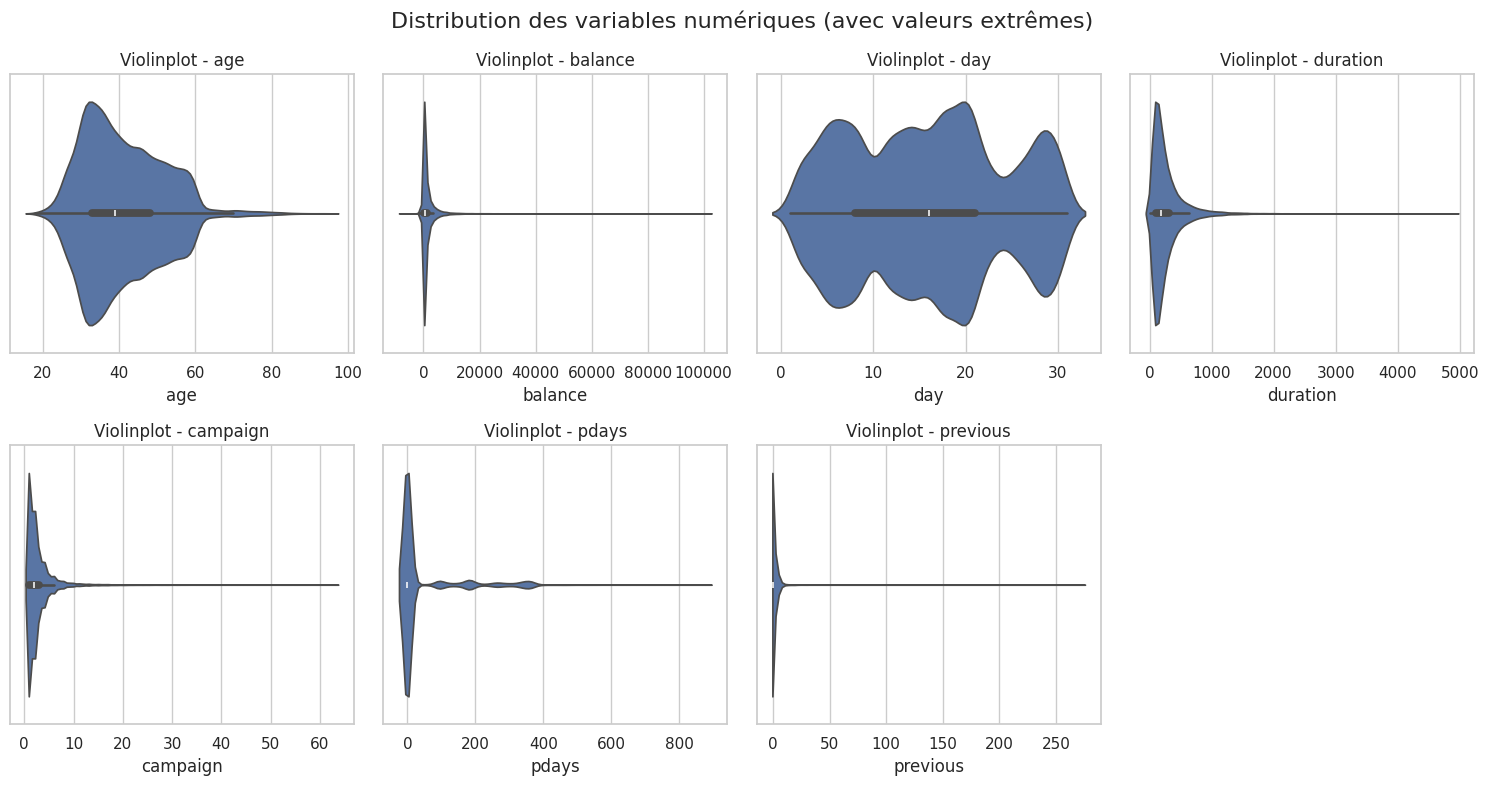

In [105]:
# Sélection des variables numériques
num_cols = data.select_dtypes(include=['int64','float64']).columns

# Nombre de variables
n = len(num_cols)

# Création de la figure
plt.figure(figsize=(15, 8))

# Boucle pour tracer chaque boxplot
for i, col in enumerate(num_cols):
    plt.subplot(2, 4, i+1)
    sns.violinplot(x=data[col])
    plt.title(f"Violinplot - {col}")

plt.suptitle("Distribution des variables numériques (avec valeurs extrêmes)", fontsize=16)
plt.tight_layout()
plt.show()

Les boxplots mettent en évidence la présence de nombreuses valeurs extrêmes, en particulier pour les variables balance, campaign et duration. Ces distributions présentent de longues queues à droite, indiquant que certaines observations prennent des valeurs beaucoup plus élevées que la majorité des données.

Ces observations semblent plausibles dans le contexte d’une campagne marketing bancaire et ne correspondent pas nécessairement à des erreurs de mesure. Elles ont donc été conservées afin de préserver l’intégrité des données et éviter l’introduction d’un biais dans l’analyse. Leur impact se situe principalement au niveau de la visualisation, certaines distributions étant fortement asymétriques.

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


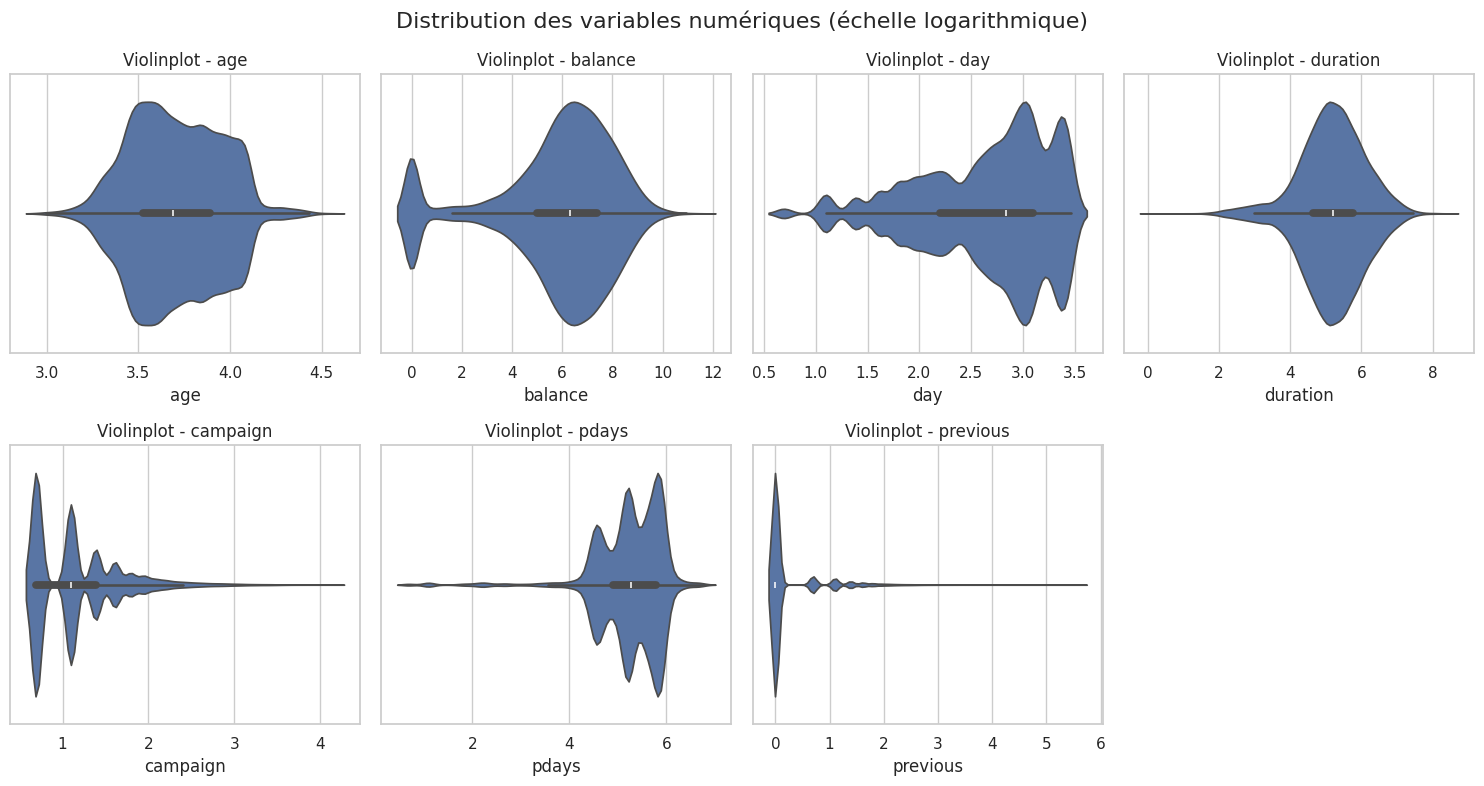

In [106]:
plt.figure(figsize=(15,8))

for i, col in enumerate(num_cols):
    plt.subplot(2,4,i+1)
    sns.violinplot(x=np.log1p(data[col]))
    plt.title(f"Violinplot - {col}")
    np.log1p(data[col].clip(lower=0))

plt.suptitle("Distribution des variables numériques (échelle logarithmique)", fontsize=16)
plt.tight_layout()
plt.show()

Afin d'améliorer la lisibilité des distributions fortement asymétriques, une visualisation complémentaire en échelle logarithmique est réalisée.
Cette représentation permet de mieux observer la dispersion centrale des variables sans supprimer les observations extrêmes du dataset.

Les valeurs extrêmes sont conservées dans le dataset car elles peuvent correspondre à des situations réelles. Toutefois, afin de limiter leur influence sur les modèles de prédiction, un traitement basé sur l’IQR sera appliqué dans le pipeline de prétraitement. Cette méthode permet de limiter l’impact des valeurs très élevées sans supprimer d’observations.

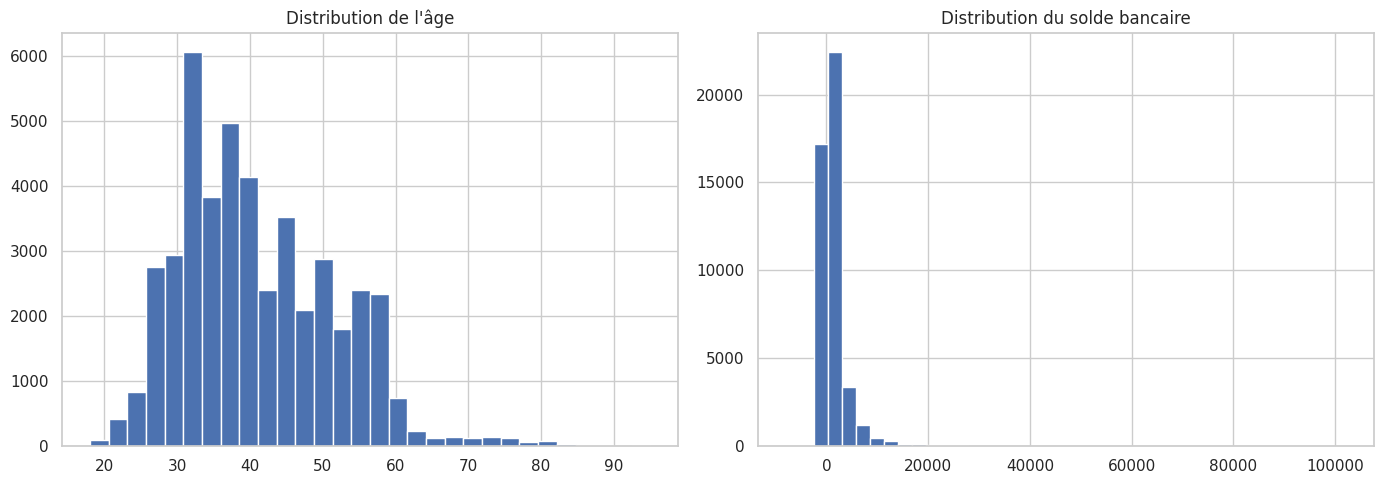

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(data["age"], bins=30)
axes[0].set_title("Distribution de l'âge")

axes[1].hist(data["balance"], bins=40)
axes[1].set_title("Distribution du solde bancaire")

plt.tight_layout()
plt.show()

Les histogrammes permettent d’observer la distribution de certaines variables numériques, notamment l’âge (age) et le solde bancaire (balance).

La distribution de l’âge présente une forme relativement concentrée autour de la tranche 30 à 50 ans, avec un pic autour d’environ 35–40 ans. Cela indique que la majorité des clients de l’échantillon se situe dans cette tranche d’âge. On observe également quelques clients plus âgés, ce qui crée une légère asymétrie vers les valeurs élevées.

La distribution du solde bancaire (balance) est fortement asymétrique à droite. La majorité des clients possède un solde relativement faible ou modéré, concentré autour de valeurs proches de zéro. Toutefois, on observe une longue queue de distribution, correspondant à un petit nombre de clients disposant de soldes très élevés. Ces valeurs extrêmes sont plausibles dans un contexte bancaire et reflètent probablement des clients disposant de ressources financières importantes.

Ces distributions indiquent que certaines variables numériques présentent une forte dispersion et des valeurs élevées peu fréquentes, ce qui devra être pris en compte lors des étapes de modélisation afin de limiter l’influence disproportionnée de ces observations.

## 8. Analyse univariée des variables catégorielles

L'objectif ici est de comprendre quelles modalités dominent dans l'échantillon.  
C'est utile pour repérer :

- les variables très déséquilibrées ;
- les modalités rares ;
- les premiers profils typiques des clients.

### But et utilité de l'étape

**But :** examiner la structure de chaque variable catégorielle (modalités dominantes, rareté, déséquilibre).

**Utilité :** anticiper les regroupements, l'encodage et l'impact potentiel sur la prédiction.


In [75]:
cat_cols = data.select_dtypes(include="object").columns.tolist()

cat_summary = pd.DataFrame({
    "n_modalites": [data[col].nunique() for col in cat_cols],
    "modalite_la_plus_frequente": [data[col].mode(dropna=False).iat[0] for col in cat_cols],
    "frequence_top": [data[col].value_counts(dropna=False).iat[0] for col in cat_cols]
}, index=cat_cols)

display(cat_summary)

,n_modalites,modalite_la_plus_frequente,frequence_top
job,12,blue-collar,9732
marital,3,married,27214
education,4,secondary,23202
default,2,no,44396
housing,2,yes,25130
loan,2,no,37967
contact,3,cellular,29285
month,12,may,13766
poutcome,4,unknown,36959
y,2,no,39922


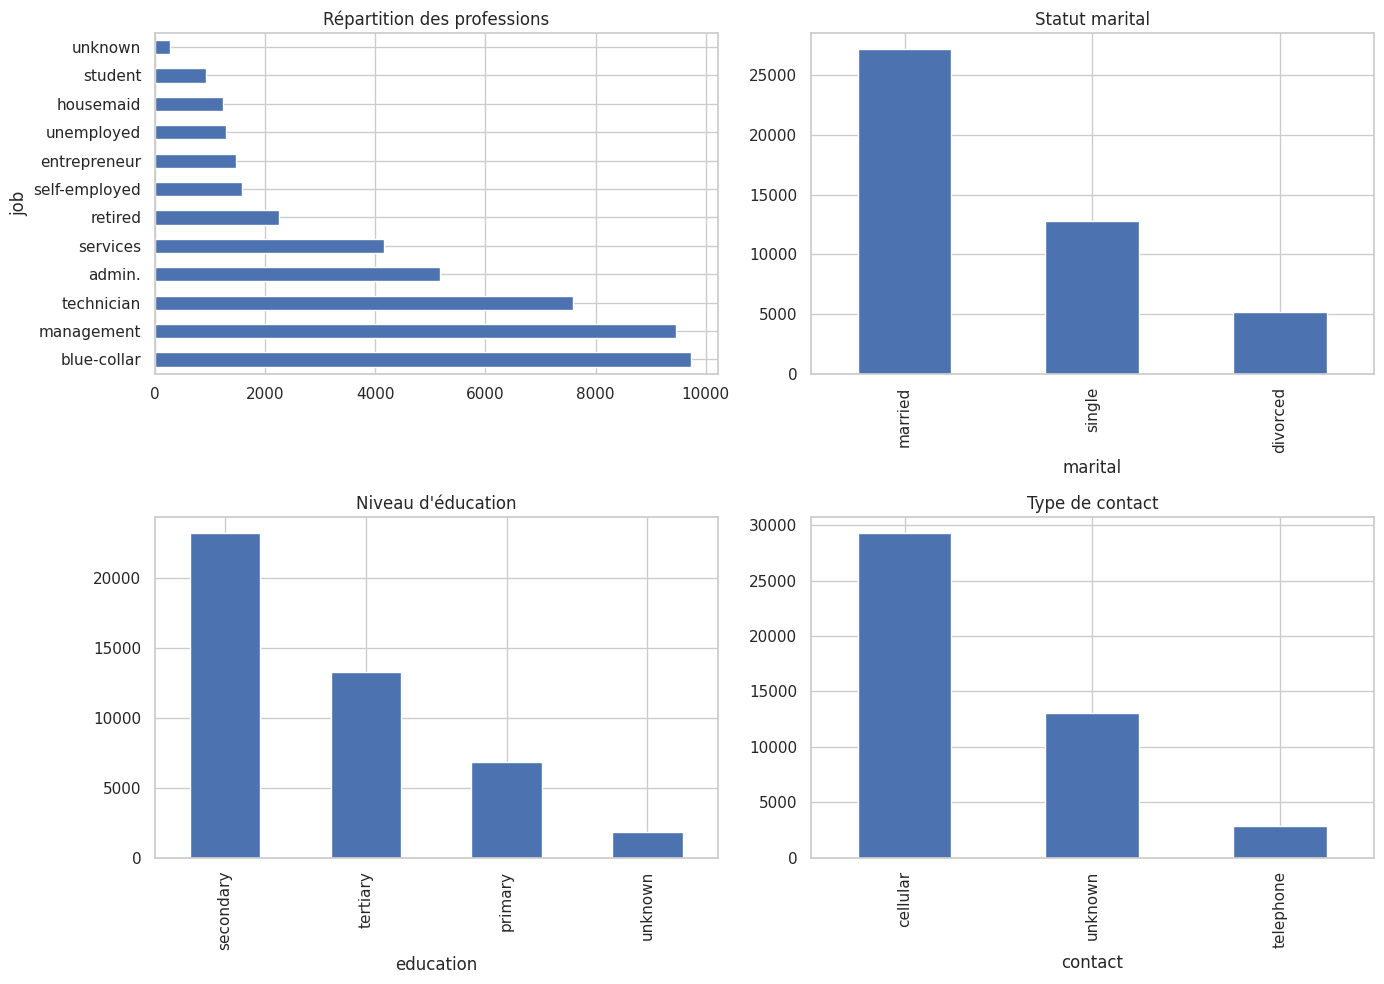

In [76]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

data["job"].value_counts().plot(kind="barh", ax=axes[0, 0])
axes[0, 0].set_title("Répartition des professions")

data["marital"].value_counts().plot(kind="bar", ax=axes[0, 1])
axes[0, 1].set_title("Statut marital")

data["education"].value_counts().plot(kind="bar", ax=axes[1, 0])
axes[1, 0].set_title("Niveau d'éducation")

data["contact"].value_counts().plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("Type de contact")

plt.tight_layout()
plt.show()

### Interprétation

Cette lecture univariée renseigne sur la structure du portefeuille clients, mais elle ne suffit pas à expliquer la souscription.  
Pour cela, il faut maintenant croiser les variables avec `y`.

## 9. Création de variables dérivées utiles pour l'EDA

Créer quelques variables plus lisibles permet souvent d'améliorer l'interprétation :

- classes d'âge ;
- historique simplifié des contacts précédents ;
- indicateur global d'endettement.

Ces variables servent surtout à l'analyse exploratoire.  
Elles ne remplacent pas automatiquement les variables d'origine dans la modélisation.

### But et utilité de l'étape

**But :** construire des variables dérivées interprétables pour enrichir la lecture du comportement client.

**Utilité :** faciliter l'exploration, faire émerger des signaux métier et préparer un feature engineering justifié.


In [77]:
eda_data = data.copy()

eda_data["age_group"] = pd.cut(
    eda_data["age"],
    bins=[18, 30, 40, 50, 60, 100],
    labels=["18-30", "31-40", "41-50", "51-60", "60+"],
    include_lowest=True
)

eda_data["previous_contact_group"] = pd.cut(
    eda_data["previous"],
    bins=[-1, 0, 4, np.inf],
    labels=["0 contact", "1 à 4 contacts", "5 contacts ou plus"]
)

eda_data["has_debt"] = ((eda_data["housing"] == "yes") | (eda_data["loan"] == "yes")).astype(int)

display(eda_data[["age_group", "previous_contact_group", "has_debt"]].head())

,age_group,previous_contact_group,has_debt
0,51-60,0 contact,1
1,41-50,0 contact,1
2,31-40,0 contact,1
3,41-50,0 contact,1
4,31-40,0 contact,0


## 10. Sauvegarde du dataset nettoyé

Avant de poursuivre, on fige une version nettoyée du dataset pour réutilisation dans les prochaines étapes.


### But et utilité de l'étape

**But :** produire une version nettoyée, traçable et réutilisable du dataset.

**Utilité :** séparer clairement les phases EDA/qualité des données et modélisation, et garantir la reproductibilité du projet.


In [78]:
dataset_clean = data.copy()

# Remplacement des unknown sur les variables catégorielles (hors cible)
cat_cols = dataset_clean.select_dtypes(include=['object', 'category']).columns.tolist()
for col in cat_cols:
    if col != 'y':
        dataset_clean[col] = dataset_clean[col].replace('unknown', np.nan)

# Traitement métier de pdays
if 'pdays' in dataset_clean.columns:
    dataset_clean['pdays_was_never_contacted'] = (dataset_clean['pdays'] == -1).astype(int)
    dataset_clean['pdays'] = dataset_clean['pdays'].replace(-1, np.nan)

# Option de nettoyage complementaire: suppression des doublons exacts
dataset_clean = dataset_clean.drop_duplicates().reset_index(drop=True)

clean_output_path = 'bank_marketing_clean.csv'
dataset_clean.to_csv(clean_output_path, index=False)
print(f'Dataset nettoyé sauvegardé : {clean_output_path}')
print(f'Dimensions: {dataset_clean.shape[0]:,} lignes x {dataset_clean.shape[1]} colonnes')


Dataset nettoyé sauvegardé : bank_marketing_clean.csv
Dimensions: 45,211 lignes x 18 colonnes


## 11. Matrice d'association adaptée aux variables mixtes

Une matrice de corrélation classique n'est pas suffisante ici, car le dataset contient à la fois :

- des variables **numériques** ;
- des variables **catégorielles**.

On construit donc une matrice d'association mixte :

- **corrélation de Pearson** pour numérique / numérique ;
- **rapport de corrélation** pour catégoriel / numérique ;
- **V de Cramér** pour catégoriel / catégoriel.

Le but n'est pas de chercher une causalité, mais de repérer les variables les plus liées à la cible.

In [79]:
def cramers_v(x, y):
    contingency = pd.crosstab(x, y)
    if contingency.empty:
        return np.nan
    chi2 = chi2_contingency(contingency)[0]
    n = contingency.to_numpy().sum()
    r, k = contingency.shape
    if n == 0 or min(r, k) <= 1:
        return np.nan
    return np.sqrt((chi2 / n) / min(r - 1, k - 1))


def correlation_ratio(categories, measurements):
    categories = pd.Series(categories)
    measurements = pd.Series(measurements)
    valid = ~(categories.isna() | measurements.isna())
    categories = categories[valid]
    measurements = measurements[valid]

    if categories.nunique() <= 1:
        return np.nan

    grand_mean = measurements.mean()
    denominator = ((measurements - grand_mean) ** 2).sum()
    if denominator == 0:
        return 0.0

    numerator = 0.0
    for cat in categories.unique():
        vals = measurements[categories == cat]
        numerator += len(vals) * (vals.mean() - grand_mean) ** 2

    return np.sqrt(numerator / denominator)


numeric_cols_eda = eda_data.select_dtypes(include=np.number).columns.tolist()
categorical_cols_eda = eda_data.select_dtypes(exclude=np.number).columns.tolist()

cols = eda_data.columns.tolist()
assoc_matrix = pd.DataFrame(index=cols, columns=cols, dtype=float)

for col1 in cols:
    for col2 in cols:
        if col1 == col2:
            assoc_matrix.loc[col1, col2] = 1.0
        elif col1 in numeric_cols_eda and col2 in numeric_cols_eda:
            assoc_matrix.loc[col1, col2] = eda_data[[col1, col2]].corr().iloc[0, 1]
        elif col1 in categorical_cols_eda and col2 in categorical_cols_eda:
            assoc_matrix.loc[col1, col2] = cramers_v(eda_data[col1], eda_data[col2])
        elif col1 in categorical_cols_eda and col2 in numeric_cols_eda:
            assoc_matrix.loc[col1, col2] = correlation_ratio(eda_data[col1], eda_data[col2])
        else:
            assoc_matrix.loc[col1, col2] = correlation_ratio(eda_data[col2], eda_data[col1])

assoc_with_target = assoc_matrix["y"].drop("y").sort_values(ascending=False)
display(assoc_with_target.to_frame("association_with_y").head(12))

,association_with_y
duration,0.395
poutcome,0.312
month,0.260
age_group,0.173
previous_contact_group,0.169
has_debt,0.159
contact,0.151
housing,0.139
job,0.136
pdays,0.104


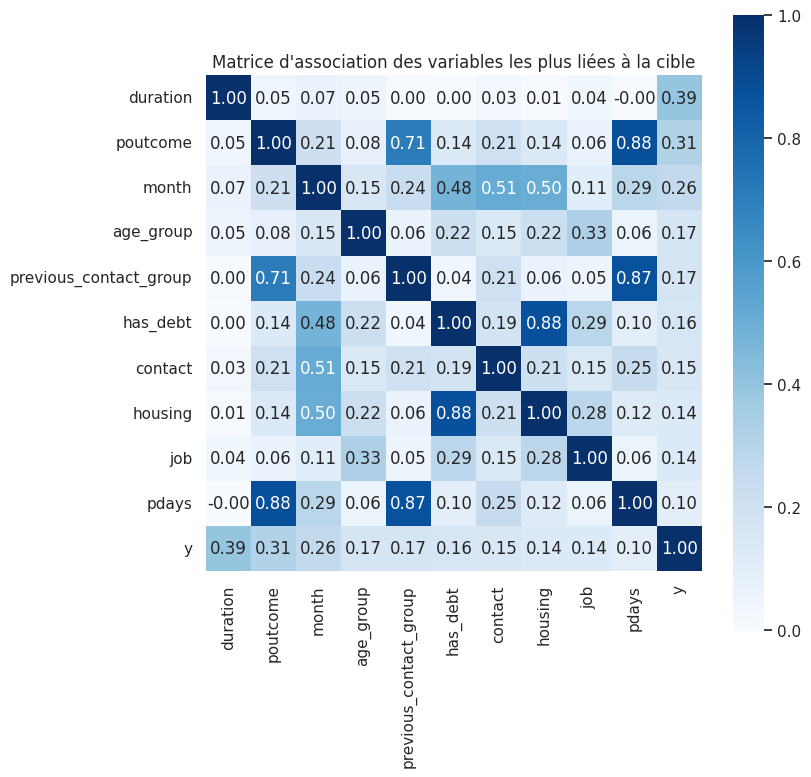

In [80]:
plt.figure(figsize=(8, 8))
sns.heatmap(assoc_matrix.loc[assoc_with_target.head(10).index.tolist() + ["y"],
                            assoc_with_target.head(10).index.tolist() + ["y"]],
            annot=True, fmt=".2f", cmap="Blues", square=True)
plt.title("Matrice d'association des variables les plus liées à la cible")
plt.show()

### Interprétation

Cette matrice permet d'identifier rapidement les variables les plus informatives vis-à-vis de `y`.  
Dans ce type de dataset, `duration`, `poutcome`, `previous` et certaines variables de contact ressortent souvent fortement.

**Attention toutefois :** une variable très liée à la cible n'est pas forcément acceptable en prédiction métier.  
C'est notamment le cas de `duration` (0.39). L’hypothèse du début du notebook selon laquelle la durée de l’appel (duration) serait très prédictive est confirmée par l’analyse statistique.
Cependant, cette variable pose un problème méthodologique important, car elle n’est connue qu’après la réalisation de l’appel. Elle ne peut donc pas être utilisée dans un modèle destiné à prédire la souscription avant de contacter le client, sous peine de créer une fuite d’information (data leakage).

## 12. Analyse bivariée ciblée

On passe maintenant à des graphiques plus directement interprétables.  
L'objectif est double :

- visualiser des différences de profil entre les clients qui souscrivent et ceux qui ne souscrivent pas ;
- préparer la discussion métier.

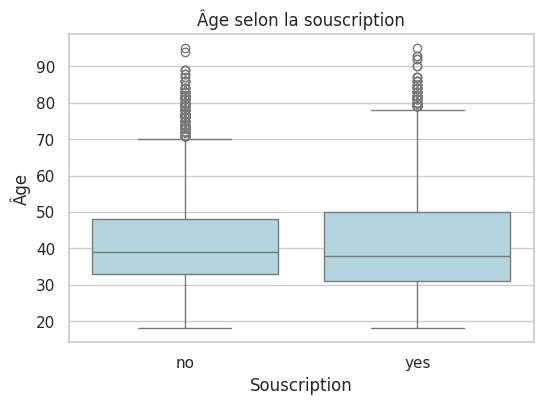

In [81]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=eda_data, x="y", y="age", color="lightblue")
plt.title("Âge selon la souscription")
plt.xlabel("Souscription")
plt.ylabel("Âge")
plt.show()

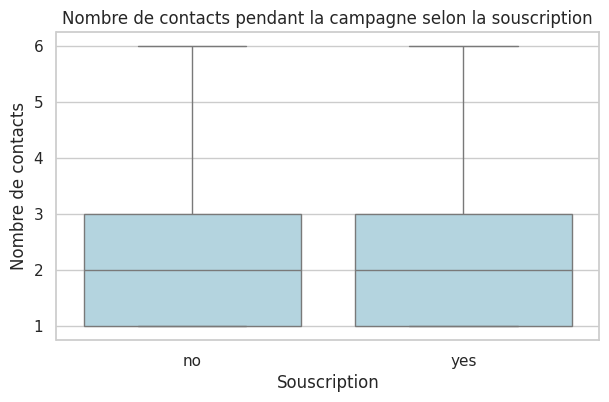

In [82]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=eda_data, x="y", y="campaign", showfliers=False, color="lightblue")
plt.title("Nombre de contacts pendant la campagne selon la souscription")
plt.xlabel("Souscription")
plt.ylabel("Nombre de contacts")
plt.show()

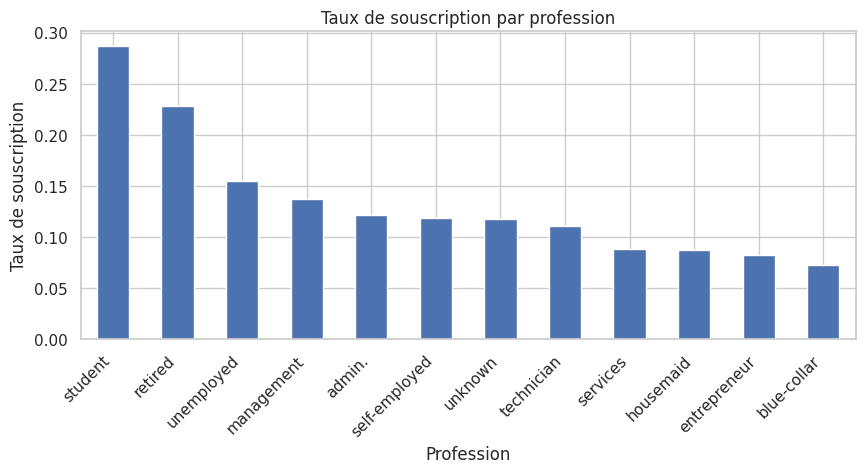

In [83]:
plt.figure(figsize=(10, 4))
order = eda_data.groupby("job")["y"].apply(lambda s: (s == "yes").mean()).sort_values(ascending=False).index

job_rate = eda_data.assign(subscribed=(eda_data["y"] == "yes").astype(int)).groupby("job")["subscribed"].mean().loc[order]
job_rate.plot(kind="bar")

plt.xticks(rotation=45, ha="right")
plt.title("Taux de souscription par profession")
plt.xlabel("Profession")
plt.ylabel("Taux de souscription")
plt.show()

L’hypothèse selon laquelle certaines professions seraient plus réceptives à l’offre est confirmée.
Le graphique met en évidence des différences notables selon les professions : les étudiants (~29 %) et les retraités (~23 %) présentent les taux de souscription les plus élevés, tandis que certaines catégories comme blue-collar (~7 %) ou entrepreneur (~8 %) affichent des taux nettement plus faibles.
Ces résultats suggèrent que la profession peut constituer une variable explicative pertinente, probablement liée au niveau de revenu, à la stabilité financière ou à la disponibilité pour les offres bancaires.

,subscription_rate
poutcome,
success,0.647
other,0.167
failure,0.126
unknown,0.092


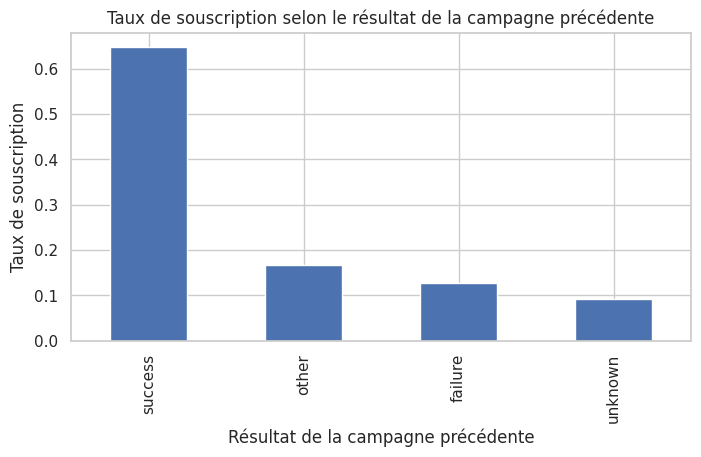

In [84]:
poutcome_rate = (
    eda_data.assign(subscribed=(eda_data["y"] == "yes").astype(int))
    .groupby("poutcome")["subscribed"]
    .mean()
    .sort_values(ascending=False)
    .to_frame("subscription_rate")
)
display(poutcome_rate)

plt.figure(figsize=(8, 4))
poutcome_rate["subscription_rate"].plot(kind="bar")
plt.title("Taux de souscription selon le résultat de la campagne précédente")
plt.xlabel("Résultat de la campagne précédente")
plt.ylabel("Taux de souscription")
plt.show()

L’hypothèse selon laquelle un client ayant déjà répondu positivement lors d’une campagne précédente serait plus susceptible de souscrire est fortement confirmée par les données.
Le graphique montre que les clients ayant eu un résultat success lors de la campagne précédente présentent un taux de souscription d’environ 65 %, contre 17 % pour "other", 12 % pour "failure" et moins de 10 % pour "unknown".
Cela suggère qu’un historique positif constitue un excellent indicateur de réceptivité future et pourrait être utilisé pour cibler prioritairement certains clients lors des campagnes marketing.

/tmp/ipykernel_213/1488529361.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  eda_data.groupby("previous_contact_group")["y"]


y,no,yes
previous_contact_group,,
0 contact,0.908,0.092
1 à 4 contacts,0.777,0.223
5 contacts ou plus,0.737,0.263


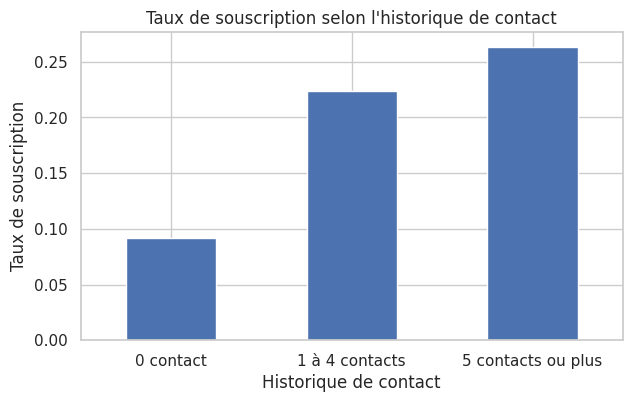

In [85]:
subscription_rate = (
    eda_data.groupby("previous_contact_group")["y"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)

display(subscription_rate)

subscription_rate["yes"].plot(kind="bar", figsize=(7, 4))
plt.title("Taux de souscription selon l'historique de contact")
plt.xlabel("Historique de contact")
plt.ylabel("Taux de souscription")
plt.xticks(rotation=0)
plt.show()

L’hypothèse selon laquelle un nombre élevé de relances traduirait une difficulté à convaincre est partiellement confirmée.
Le graphique sur l’historique de contact montre que le taux de souscription varie selon l’intensité du contact : les clients n’ayant aucun contact présentent un taux d’environ 9 %, tandis que ceux ayant 1 à 4 contacts atteignent environ 22 %, et ceux ayant 5 contacts ou plus environ 26 %.
Cela suggère que le fait d’insister peut augmenter les conversions, mais peut aussi refléter une sélection progressive des clients les plus intéressés, ce qui complique l’interprétation causale.

y,no,yes
has_debt,,
0,0.818,0.182
1,0.923,0.077


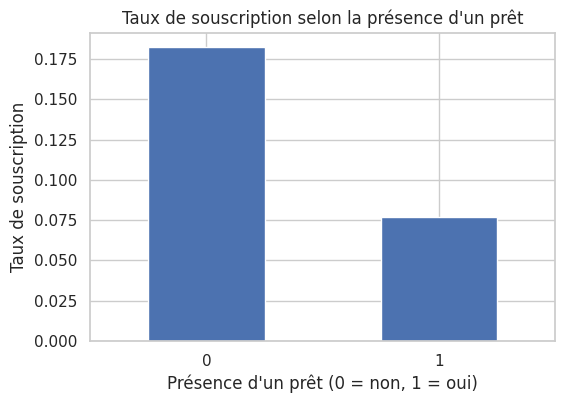

In [86]:
debt_subscription_rate = (
    eda_data.groupby("has_debt")["y"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)

display(debt_subscription_rate)

debt_subscription_rate["yes"].plot(kind="bar", figsize=(6, 4))
plt.title("Taux de souscription selon la présence d'un prêt")
plt.xlabel("Présence d'un prêt (0 = non, 1 = oui)")
plt.ylabel("Taux de souscription")
plt.xticks(rotation=0)
plt.show()

### Synthèse EDA

Plusieurs signaux ressortent :

- un **résultat positif à la campagne précédente** est très fortement associé à une nouvelle souscription ;
- un **nombre élevé de contacts** au cours de la campagne ne semble pas être synonyme d'efficacité ;
- certaines professions apparaissent plus réceptives que d'autres ;
- l'endettement peut jouer un rôle, mais l'effet semble moins fort que l'historique marketing.

Ces constats sont utiles pour l'interprétation, mais ils doivent maintenant être consolidés par quelques tests statistiques.

## 13. Tests statistiques ciblés

Le cahier des charges demande d'aller au-delà des visualisations descriptives.  
On réalise donc deux tests simples :

1. **test du chi²** pour une relation entre deux variables catégorielles ;
2. **test de Mann-Whitney** pour comparer une variable numérique entre les deux classes.

Ces tests ne prouvent pas une causalité, mais ils permettent de vérifier si les écarts observés sont compatibles ou non avec l'hypothèse d'indépendance.

In [87]:
def chi2_test_table(df, feature, target="y"):
    table = pd.crosstab(df[feature], df[target])
    chi2, p_value, dof, _ = chi2_contingency(table)
    return pd.DataFrame({
        "feature": [feature],
        "chi2": [chi2],
        "p_value": [p_value],
        "degrees_of_freedom": [dof]
    })

chi2_results = pd.concat([
    chi2_test_table(data, "job"),
    chi2_test_table(data, "education"),
    chi2_test_table(data, "housing"),
    chi2_test_table(data, "poutcome")
], ignore_index=True)

display(chi2_results.sort_values("p_value"))

,feature,chi2,p_value,degrees_of_freedom
3,poutcome,"4,391.507",0.000,3
2,housing,874.822,0.000,1
0,job,836.105,0.000,11
1,education,238.924,0.000,3


In [88]:
group_no = data.loc[data["y"] == "no", "age"]
group_yes = data.loc[data["y"] == "yes", "age"]

stat, p_value = mannwhitneyu(group_no, group_yes, alternative="two-sided")

mw_result = pd.DataFrame({
    "variable": ["age"],
    "test": ["Mann-Whitney"],
    "statistic": [stat],
    "p_value": [p_value],
    "median_no": [group_no.median()],
    "median_yes": [group_yes.median()]
})

display(mw_result)

,variable,test,statistic,p_value,median_no,median_yes
0,age,Mann-Whitney,"107,232,348.500",0.063,39.000,38.000


### Interprétation des tests

Lorsque la **p-value** est très faible, on rejette l'hypothèse d'indépendance ou d'égalité de distribution.

Ici, cela signifie que certaines variables comme `poutcome` ou `job` ne semblent pas réparties au hasard par rapport à la cible.  
De même, si l'âge présente une différence statistiquement significative, cela confirme qu'il existe un écart global entre les groupes `yes` et `no`, même si cet écart peut rester modéré visuellement.

**Important :** avec un grand dataset, une différence peut être statistiquement significative sans être très forte en pratique.  
Il faut donc toujours croiser les tests avec l'interprétation métier.

## 14. Stratégie de modélisation

### Choix important : exclusion de `duration`

`duration` est souvent la variable la plus prédictive, car un appel long est fréquemment associé à une interaction plus engageante.  
Mais cette information n'est connue **qu'après** avoir appelé le client.

Or l'objectif métier est de décider **qui contacter avant l'appel**.  
Inclure `duration` donnerait donc un modèle artificiellement performant, mais inutilisable en ciblage réel.

On construit donc les modèles sur un jeu de variables **pré-appel**.

### But et utilité de l'étape

**But :** définir explicitement la préparation Machine Learning (split, pipelines, métriques, comparaison de modèles).

**Utilité :** obtenir une évaluation fiable des performances et limiter les fuites entre entraînement et test.


In [89]:
class BankFeatureCleaner(BaseEstimator, TransformerMixin):
    """Nettoyage métier :
    - remplace les 'unknown' par NaN ;
    - crée un indicateur pour pdays = -1 ;
    - remplace pdays = -1 par NaN.
    """
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
        for col in cat_cols:
            X[col] = X[col].replace("unknown", np.nan)

        if "pdays" in X.columns:
            X["pdays_was_never_contacted"] = (X["pdays"] == -1).astype(int)
            X["pdays"] = X["pdays"].replace(-1, np.nan)

        return X


class IQRClipper(BaseEstimator, TransformerMixin):
    """Clipping basé sur l'IQR pour limiter l'impact des valeurs extrêmes."""
    def __init__(self, factor=1.5):
        self.factor = factor

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X).copy()
        self.columns_ = X_df.columns.tolist()
        q1 = X_df.quantile(0.25)
        q3 = X_df.quantile(0.75)
        iqr = q3 - q1
        self.lower_ = q1 - self.factor * iqr
        self.upper_ = q3 + self.factor * iqr
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X, columns=self.columns_).copy()
        return X_df.clip(lower=self.lower_, upper=self.upper_, axis=1)

    def get_feature_names_out(self, input_features=None):
        return np.array(input_features if input_features is not None else self.columns_)

In [90]:
model_data = data.copy()

# Exclusion de la cible et de duration (fuite d'information)
X = model_data.drop(columns=["y", "duration"])
y = model_data["y"].map({"no": 0, "yes": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# On nettoie d'abord un échantillon d'entraînement pour identifier les types de colonnes
X_train_clean = BankFeatureCleaner().fit_transform(X_train)
num_features = X_train_clean.select_dtypes(include=np.number).columns.tolist()
cat_features = X_train_clean.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("clipper", IQRClipper(factor=1.5)),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_features),
    ("cat", categorical_pipeline, cat_features)
])

print("Variables numériques :", num_features)
print("Variables catégorielles :", cat_features)

Variables numériques : ['age', 'balance', 'day', 'campaign', 'pdays', 'previous', 'pdays_was_never_contacted']
Variables catégorielles : ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


### Pourquoi ce pipeline ?

Ce pipeline permet de rendre l'analyse **reproductible** et d'éviter les fuites entre entraînement et test.

- **imputation médiane** : robuste aux valeurs extrêmes ;
- **clipping IQR** : réduit l'effet des outliers ;
- **standardisation** : utile pour la régression logistique ;
- **one-hot encoding** : transforme les modalités textuelles en variables exploitables par les modèles.

## 15. Modèles comparés

On compare volontairement des approches différentes :

- **Régression logistique (LR)** : modèle simple, robuste et interprétable ;
- **Decision Tree Classifier (DTC)** : arbre unique, lisible et rapide à entraîner ;
- **Random Forest Classifier (RFC)** : ensemble d'arbres réduisant la variance ;
- **Extra Trees Classifier (ETC)** : variante d'arbres avec plus d'aléa, souvent robuste ;
- **XGBoost (XGBC)** : gradient boosting souvent performant sur des données tabulaires ;
- **Voting Classifier** : ensemble qui agrège plusieurs modèles.

Cette comparaison est importante pour répondre au cahier des charges et montrer qu'on ne dépend pas d'un seul algorithme.


In [91]:
models = {
    "Régression logistique (LR)": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="lbfgs"
    ),
    "Decision Tree (DTC)": DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=5,
        random_state=42,
        class_weight="balanced"
    ),
    "Random Forest (RFC)": RandomForestClassifier(
        n_estimators=250,
        max_depth=10,
        min_samples_leaf=4,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample"
    ),
    "Extra Trees (ETC)": ExtraTreesClassifier(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample"
    )
}

if HAS_XGBOOST:
    models["XGBoost (XGBC)"] = XGBClassifier(
        n_estimators=250,
        max_depth=4,
        learning_rate=0.08,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=4
    )

display(pd.DataFrame({"Modèles comparés": list(models.keys())}))


,Modèles comparés
0,Régression logistique (LR)
1,Decision Tree (DTC)
2,Random Forest (RFC)
3,Extra Trees (ETC)
4,XGBoost (XGBC)


### Pourquoi ajouter DTC et ETC ?

**But :** enrichir le benchmark avec des modèles d'arbres de complexité différente.

**Utilité :** vérifier si un modèle simple (DTC) ou un ensemble plus aléatoire (ETC) offre un meilleur compromis précision/rappel que LR, RFC et XGBC.


## 16. Validation croisée comparative

On utilise une **validation croisée stratifiée** pour obtenir une estimation plus fiable des performances qu'un simple score sur un seul découpage.

Pourquoi la validation croisée ?

- elle réduit la dépendance à un split unique ;
- elle donne une vision plus stable de la généralisation ;
- elle aide à comparer les modèles de manière plus juste.

In [92]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_rows = []

for model_name, model in models.items():
    pipe = Pipeline([
        ("cleaner", BankFeatureCleaner()),
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipe,
        X,
        y,
        cv=cv,
        scoring=["roc_auc", "f1", "precision", "recall", "accuracy"],
        n_jobs=1
    )

    cv_rows.append({
        "Modèle": model_name,
        "ROC_AUC_CV": scores["test_roc_auc"].mean(),
        "F1_CV": scores["test_f1"].mean(),
        "Precision_CV": scores["test_precision"].mean(),
        "Recall_CV": scores["test_recall"].mean(),
        "Accuracy_CV": scores["test_accuracy"].mean()
    })

cv_results = pd.DataFrame(cv_rows).sort_values("ROC_AUC_CV", ascending=False).reset_index(drop=True)
display(cv_results)

,Modèle,ROC_AUC_CV,F1_CV,Precision_CV,Recall_CV,Accuracy_CV
0,XGBoost (XGBC),0.783,0.335,0.628,0.228,0.894
1,Random Forest (RFC),0.764,0.407,0.318,0.564,0.808
2,Extra Trees (ETC),0.759,0.397,0.304,0.575,0.796
3,Régression logistique (LR),0.750,0.373,0.271,0.599,0.765
4,Decision Tree (DTC),0.716,0.367,0.284,0.522,0.788


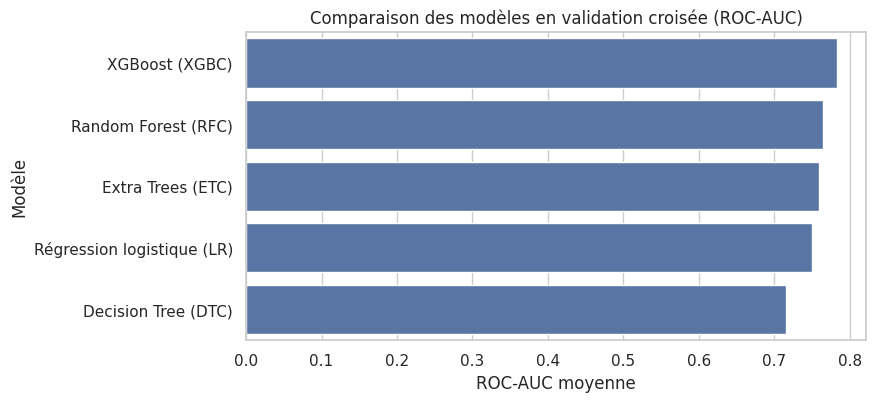

In [93]:
plt.figure(figsize=(8, 4))
sns.barplot(data=cv_results, x="ROC_AUC_CV", y="Modèle")
plt.title("Comparaison des modèles en validation croisée (ROC-AUC)")
plt.xlabel("ROC-AUC moyenne")
plt.ylabel("Modèle")
plt.show()

### Interprétation

Le classement par ROC-AUC aide à choisir un bon point de départ, mais notre objectif n'est pas uniquement de gagner quelques points de score.  
Le vrai enjeu est de **mieux cibler les appels** : contacter en priorité les clients avec une probabilité réaliste de souscription, sans saturer les équipes commerciales avec trop de faux positifs.

Concrètement :

- un **rappel élevé** augmente les chances de capter des clients intéressés ;
- une **précision élevée** réduit les appels peu utiles ;
- le bon compromis dépend du coût d'un appel, de la capacité de l'équipe et de la valeur d'une souscription.

Le meilleur modèle est donc celui qui sert le mieux la stratégie de campagne, pas seulement celui qui a le score le plus élevé.


## 17. Entraînement final du meilleur modèle

On retient ici le modèle ayant la meilleure **ROC-AUC moyenne en validation croisée**, puis on l'évalue proprement sur le jeu de test séparé au départ.

In [94]:
best_model_name = cv_results.loc[0, "Modèle"]
best_model = models[best_model_name]

final_pipeline = Pipeline([
    ("cleaner", BankFeatureCleaner()),
    ("preprocessor", preprocessor),
    ("model", best_model)
])

final_pipeline.fit(X_train, y_train)

y_proba = final_pipeline.predict_proba(X_test)[:, 1]
y_pred_default = (y_proba >= 0.5).astype(int)

test_metrics_default = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Value": [
        accuracy_score(y_test, y_pred_default),
        precision_score(y_test, y_pred_default),
        recall_score(y_test, y_pred_default),
        f1_score(y_test, y_pred_default),
        roc_auc_score(y_test, y_proba)
    ]
})

print(f"Modèle retenu : {best_model_name}")
display(test_metrics_default)

Modèle retenu : XGBoost (XGBC)


,Metric,Value
0,Accuracy,0.896
1,Precision,0.660
2,Recall,0.233
3,F1-score,0.345
4,ROC-AUC,0.788


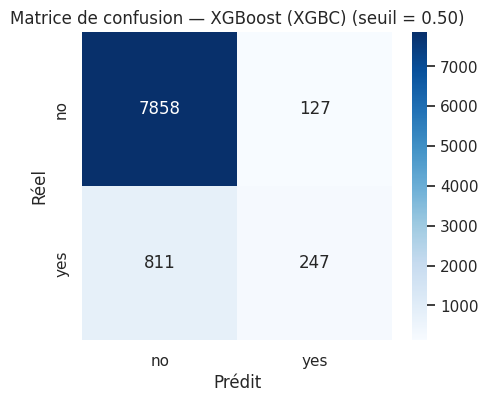

              precision    recall  f1-score   support

          no       0.91      0.98      0.94      7985
         yes       0.66      0.23      0.34      1058

    accuracy                           0.90      9043
   macro avg       0.78      0.61      0.64      9043
weighted avg       0.88      0.90      0.87      9043



In [95]:
cm_default = confusion_matrix(y_test, y_pred_default)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_default, annot=True, fmt="d", cmap="Blues",
            xticklabels=["no", "yes"], yticklabels=["no", "yes"])
plt.title(f"Matrice de confusion — {best_model_name} (seuil = 0.50)")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

print(classification_report(y_test, y_pred_default, target_names=["no", "yes"]))

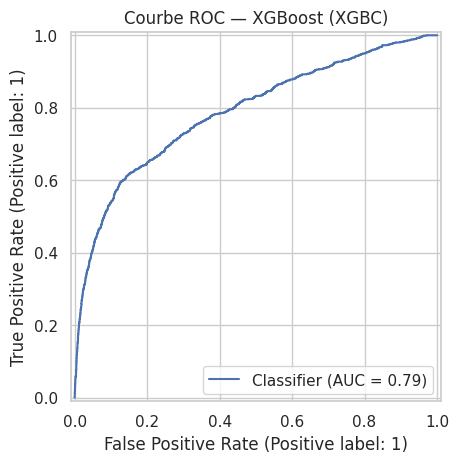

In [96]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title(f"Courbe ROC — {best_model_name}")
plt.show()

### Lecture des résultats au seuil standard

Le seuil 0,50 est un repère technique, pas une règle métier.

Pour une campagne marketing, la bonne question est : **que veut-on optimiser opérationnellement ?**

- si l'objectif est de ne pas rater de profils intéressants, on privilégie davantage le **rappel** ;
- si l'objectif est de limiter les coûts et la pression commerciale, on privilégie davantage la **précision**.

Tester plusieurs seuils permet de transformer un modèle statistique en un outil de pilotage campagne réellement exploitable.


## 18. Ajustement du seuil de décision

Un modèle de classification renvoie des probabilités.  
Le passage en classe `yes` ou `no` dépend ensuite d'un **seuil de décision**.

Cette étape est essentielle car elle rapproche le modèle d'un **usage métier réel**.

In [97]:
thresholds = np.arange(0.10, 0.55, 0.05)

threshold_rows = []
for threshold in thresholds:
    pred_thr = (y_proba >= threshold).astype(int)
    threshold_rows.append({
        "threshold": round(float(threshold), 2),
        "accuracy": accuracy_score(y_test, pred_thr),
        "precision": precision_score(y_test, pred_thr, zero_division=0),
        "recall": recall_score(y_test, pred_thr, zero_division=0),
        "f1": f1_score(y_test, pred_thr, zero_division=0),
        "predicted_yes_rate": pred_thr.mean()
    })

threshold_table = pd.DataFrame(threshold_rows)
display(threshold_table)

,threshold,accuracy,precision,recall,f1,predicted_yes_rate
0,0.100,0.750,0.272,0.678,0.388,0.292
1,0.150,0.851,0.403,0.564,0.470,0.164
2,0.200,0.874,0.463,0.474,0.469,0.120
3,0.250,0.885,0.510,0.429,0.466,0.099
4,0.300,0.889,0.538,0.384,0.448,0.083
5,0.350,0.894,0.578,0.345,0.432,0.070
6,0.400,0.896,0.611,0.310,0.411,0.059
7,0.450,0.897,0.639,0.271,0.381,0.050
8,0.500,0.896,0.660,0.233,0.345,0.041


In [98]:
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_proba)

f2_scores = (5 * precision[:-1] * recall[:-1]) / (4 * precision[:-1] + recall[:-1] + 1e-9)
best_idx = np.nanargmax(f2_scores)
best_threshold_f2 = float(pr_thresholds[best_idx])

y_pred_f2 = (y_proba >= best_threshold_f2).astype(int)

threshold_comparison = pd.DataFrame({
    "Scenario": ["Seuil standard 0.50", f"Seuil optimisé F2 ({best_threshold_f2:.2f})"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_default),
        accuracy_score(y_test, y_pred_f2)
    ],
    "Precision": [
        precision_score(y_test, y_pred_default),
        precision_score(y_test, y_pred_f2)
    ],
    "Recall": [
        recall_score(y_test, y_pred_default),
        recall_score(y_test, y_pred_f2)
    ],
    "F1-score": [
        f1_score(y_test, y_pred_default),
        f1_score(y_test, y_pred_f2)
    ],
    "Prospects_ciblés_%": [
        y_pred_default.mean() * 100,
        y_pred_f2.mean() * 100
    ]
})

display(threshold_comparison)

,Scenario,Accuracy,Precision,Recall,F1-score,Prospects_ciblés_%
0,Seuil standard 0.50,0.896,0.660,0.233,0.345,4.136
1,Seuil optimisé F2 (0.13),0.829,0.363,0.611,0.455,19.673


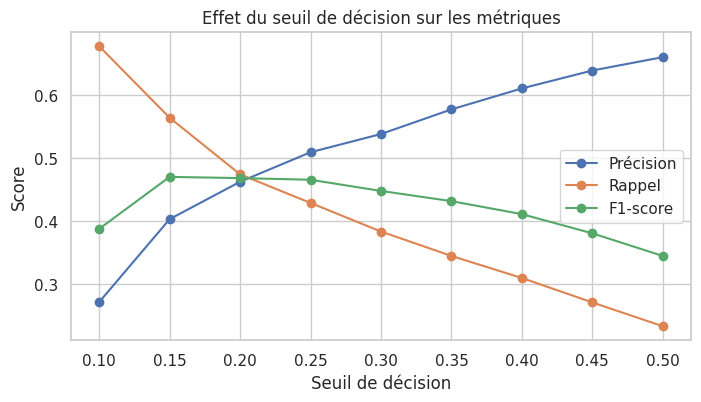

In [99]:
plt.figure(figsize=(8, 4))
plt.plot(threshold_table["threshold"], threshold_table["precision"], marker="o", label="Précision")
plt.plot(threshold_table["threshold"], threshold_table["recall"], marker="o", label="Rappel")
plt.plot(threshold_table["threshold"], threshold_table["f1"], marker="o", label="F1-score")
plt.xlabel("Seuil de décision")
plt.ylabel("Score")
plt.title("Effet du seuil de décision sur les métriques")
plt.legend()
plt.show()

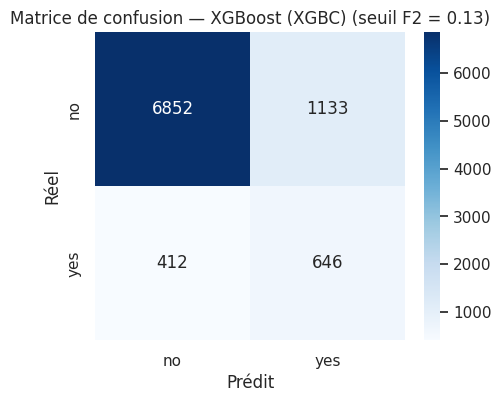

In [100]:
cm_f2 = confusion_matrix(y_test, y_pred_f2)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_f2, annot=True, fmt="d", cmap="Blues",
            xticklabels=["no", "yes"], yticklabels=["no", "yes"])
plt.title(f"Matrice de confusion — {best_model_name} (seuil F2 = {best_threshold_f2:.2f})")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

### Interprétation métier

L'ajustement du seuil est une décision business, pas seulement une décision data.

- Un seuil plus bas = plus d'opportunités détectées, mais aussi plus d'appels "inutiles".
- Un seuil plus haut = moins d'appels, mais risque de manquer des clients qui auraient pu souscrire.

Pour cette étude, l'idée est d'identifier le **profil le plus susceptible de souscrire** tout en gardant un volume d'actions soutenable.  
Le seuil retenu doit donc être aligné avec la capacité commerciale et les objectifs de conversion de la campagne.


## 19. Importance des variables du meilleur modèle

L'interprétation des variables importantes aide à relier la partie machine learning à la compréhension métier.

On extrait ici les variables transformées après le préprocessing pour visualiser celles qui pèsent le plus dans la décision du modèle.

In [101]:
preprocessor_fitted = final_pipeline.named_steps["preprocessor"]
feature_names = preprocessor_fitted.get_feature_names_out()

if best_model_name == "Régression logistique":
    importance_values = final_pipeline.named_steps["model"].coef_[0]
else:
    importance_values = final_pipeline.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importance_values,
    "abs_importance": np.abs(importance_values)
}).sort_values("abs_importance", ascending=False)

display(importance_df.head(15))

,feature,importance,abs_importance
37,cat__poutcome_success,0.292,0.292
31,cat__month_mar,0.090,0.090
22,cat__housing_yes,0.068,0.068
34,cat__month_oct,0.055,0.055
35,cat__month_sep,0.049,0.049
26,cat__month_dec,0.032,0.032
27,cat__month_feb,0.028,0.028
32,cat__month_may,0.026,0.026
23,cat__loan_yes,0.024,0.024
0,num__age,0.020,0.020


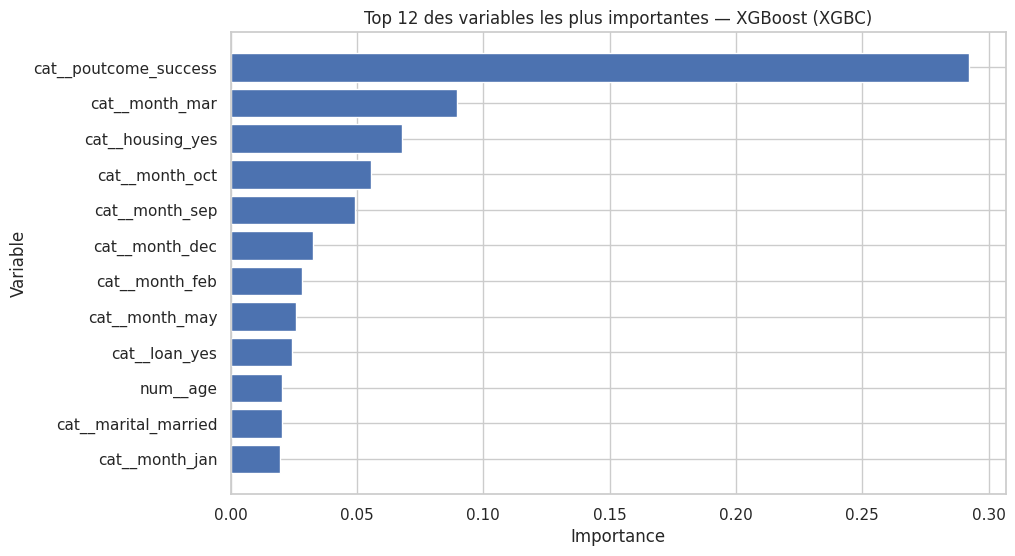

In [102]:
plot_df = importance_df.head(12).sort_values("importance")

plt.figure(figsize=(10, 6))
plt.barh(plot_df["feature"], plot_df["importance"])
plt.title(f"Top 12 des variables les plus importantes — {best_model_name}")
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.show()

### Interprétation

La liste des variables importantes doit être lue comme un **guide d'action marketing** plutôt qu'une vérité absolue.

- Ces variables aident à comprendre **quels profils répondent mieux** ;
- Elles mettent en évidence des **facteurs de succès** (profils/historiques favorables) et des **facteurs d'échec** (profils peu réactifs).

Attention : importance ne veut pas dire causalité.  
Mais c'est suffisant pour orienter une campagne plus ciblée : prioriser les segments prometteurs, adapter le message et limiter les relances sur des profils historiquement peu convertis.


## 20. Voting Classifier — modèle d'ensemble

Pour aller plus loin, on construit un **modèle d'ensemble** qui combine plusieurs algorithmes.  
Ici, on agrège prioritairement **LR + DTC + RFC** (et **XGBC** si disponible) en vote soft.

L'idée est simple : si plusieurs modèles captent des signaux complémentaires, leur combinaison peut améliorer la robustesse.


In [103]:
base_estimators = [
    ("lr", LogisticRegression(max_iter=2000, class_weight="balanced", solver="lbfgs")),
    ("dtc", DecisionTreeClassifier(
        max_depth=8,
        min_samples_leaf=5,
        random_state=42,
        class_weight="balanced"
    )),
    ("rfc", RandomForestClassifier(
        n_estimators=250,
        max_depth=10,
        min_samples_leaf=4,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced_subsample"
    ))
]

if HAS_XGBOOST:
    base_estimators.append(("xgbc", XGBClassifier(
        n_estimators=250,
        max_depth=4,
        learning_rate=0.08,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=4
    )))

voting_clf = VotingClassifier(
    estimators=base_estimators,
    voting="soft",
    n_jobs=-1
)

voting_pipeline = Pipeline([
    ("cleaner", BankFeatureCleaner()),
    ("preprocessor", preprocessor),
    ("model", voting_clf)
])

voting_pipeline.fit(X_train, y_train)
y_proba_voting = voting_pipeline.predict_proba(X_test)[:, 1]
y_pred_voting = (y_proba_voting >= 0.5).astype(int)

test_metrics_voting = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Voting_Classifier": [
        accuracy_score(y_test, y_pred_voting),
        precision_score(y_test, y_pred_voting),
        recall_score(y_test, y_pred_voting),
        f1_score(y_test, y_pred_voting),
        roc_auc_score(y_test, y_proba_voting)
    ]
})

display(test_metrics_voting)


,Metric,Voting_Classifier
0,Accuracy,0.875
1,Precision,0.464
2,Recall,0.457
3,F1-score,0.461
4,ROC-AUC,0.772


In [104]:
comparison_test = test_metrics_default.merge(test_metrics_voting, on="Metric", how="left")
comparison_test = comparison_test.rename(columns={"Value": best_model_name})
display(comparison_test)

,Metric,XGBoost (XGBC),Voting_Classifier
0,Accuracy,0.896,0.875
1,Precision,0.660,0.464
2,Recall,0.233,0.457
3,F1-score,0.345,0.461
4,ROC-AUC,0.788,0.772


### Lecture comparative

Le Voting Classifier est utile pour tester une stratégie "collective" : combiner plusieurs points de vue modèles pour stabiliser la prédiction.

Si le gain est faible, un modèle simple et lisible reste souvent préférable en contexte métier :

- il est plus facile à expliquer aux équipes commerciales ;
- il permet de justifier clairement pourquoi un client est ciblé ;
- il facilite l'appropriation opérationnelle des facteurs de succès/échec de la campagne.


## 21. Limites de l'analyse

Aucune modélisation n'est parfaite. Les principales limites ici sont les suivantes :

1. **Déséquilibre de la cible** : la classe positive reste minoritaire.
2. **Variable `duration` exclue** : cela réduit le score brut, mais rend le modèle réaliste en phase de ciblage pré-appel.
3. **Modalités `unknown`** : leur signification exacte reste ambiguë.
4. **Absence d'informations externes** : on ne dispose pas, par exemple, du coût détaillé des appels ni de la valeur client long terme.
5. **Temporalité limitée** : les comportements clients peuvent évoluer d'une campagne à l'autre.

Ces limites n'annulent pas la valeur du modèle : elles rappellent surtout que la prédiction doit rester un **outil d'aide à la décision**, à compléter par le contexte métier et le retour terrain.


## 22. Conclusion générale

Cette analyse répond à l'objectif principal du travail : **prédire le profil client le plus susceptible de souscrire** et dégager des leviers concrets pour améliorer la campagne.

### Conclusion métier

- Le modèle permet de mieux hiérarchiser les clients à contacter, au lieu de traiter tout le portefeuille de la même façon.
- Les variables liées à l'historique de contact et au contexte de campagne ressortent comme des **facteurs clés de succès/échec**.
- Les performances doivent être lues avec une logique opérationnelle : l'intérêt n'est pas seulement d'avoir un bon score, mais d'améliorer le taux de conversion utile.
- Le choix du seuil est stratégique : il traduit le niveau de risque commercial accepté entre "rater des souscriptions" et "sur-solliciter des profils peu réactifs".

En pratique, ce notebook fournit une base robuste pour un ciblage plus intelligent :

1. identifier les segments à fort potentiel ;
2. réduire les actions peu rentables ;
3. mieux comprendre pourquoi une campagne réussit ou échoue selon les profils clients.
